# Model Development & Tracking 
Covers **Stage 2.2–2.4 + Stage 3.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 

- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/model.py`, `src/train.py`, `app.py`. 
- *You build:* this notebook.

### 0. Setup

In [ ]:
import config
# TODO: imports (torch, mlflow, pandas, matplotlib) as needed


In [1]:
import torch
import torch.nn as nn
import torchvision

import pandas as pd
import matplotlib.pyplot as plt

import mlflow

import config

In [87]:
import importlib
from src import model

# Reload project module after making changes
importlib.reload(model)

<module 'src.model' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\model.py'>

In [96]:
import importlib
from src import train

importlib.reload(train)
from src.train import train_one_epoch

weights = train.class_weights(train_items)

In [ ]:
import importlib
from src import train
from src import evaluate
from src import model
from src import data_prep

importlib.reload(train)
importlib.reload(evaluate)
importlib.reload(model)
importlib.reload(data_prep)

## **Stage 2.2 — Transfer-Learning Model** <font color="red">[7 marks]</font>

- **2.2.1 — ImageNet-pretrained ResNet18, backbone frozen [4]**
- **2.2.2 — New 2-class head replaces fc (head trained) [3]**

**Objective:** Build an ImageNet-pretrained ResNet18 with a frozen backbone + new 2-class head.

**Implement in:** src/model.build_model

**Inputs → Outputs:** → a torch model; only the head's params have requires_grad=True

**TODO:** load weights=IMAGENET1K + freeze the backbone (2.2.1); replace fc with a 2-class Linear head so only the head trains (2.2.2); print total vs trainable params.

**Depends on:** Stage 2.1 transformations completed in Data_Preparation.ipynb  ·  **Document here:** the param counts (trainable should be ~the head only).

In [ ]:
# TODO 2.2.1-2.2.2: from src.model import build_model, trainable_parameters; build + print params


In [4]:
from src.model import build_model

model = build_model(freeze=False)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Abhinav/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 11.0MB/s]


Total Parameters     : 11,177,538
Trainable Parameters : 11,177,538
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [7]:
import importlib
from src import model

importlib.reload(model)

net = model.build_model(freeze=True)

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512


Transfer Learning Configuration

Loaded an ImageNet-pretrained ResNet18.
Replaced the original 1000-class fully connected layer with a new 2-class classifier.
Froze all backbone parameters to retain pretrained feature representations.
Only the new classification head remains trainable.

Model Statistics

Total Parameters: 11,177,538
Trainable Parameters: 1,026
Frozen Parameters: 11,176,512

## **Stage 2.3 — Training Workflow** <font color="red">[6 marks]</font>

- **2.3.1 — Class-weighted loss + optimiser (trainable params) + seed [3]**
- **2.3.2 — Epoch loop + validation eval + early stopping [3]**

**Objective:** Train the head reproducibly with validation + early stopping.

**Implement in:** src/train.py

**Inputs → Outputs:** splits + model → trained model.pt + model_meta.json

**TODO:** class-weighted CrossEntropy + Adam over TRAINABLE params only + seed 42 (2.3.1); epoch loop with val evaluation + early stop on val-F1 (2.3.2).

**Document here:** the training summary (final val F1, epochs).

In [ ]:
# TODO 2.3.1-2.3.2: !python -m src.train   (then load artifacts/model_meta.json)


In [8]:
from src import data_prep

root = data_prep.find_data_root()
data_prep.build_splits(root, "v1")


Class Distribution After Split
ok_front    Train : 34   Validation :  6
def_front   Train : 34   Validation :  6

Stratified split completed
Training Samples   : 68
Validation Samples : 12

Prepared Split Records
Train      : 68
Validation : 12
Test       : 80
Saved: train.json (68 images)
Saved: val.json (12 images)
Saved: test.json (80 images)
Saved: metadata.json
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80


{'dataset_version': 'v1',
 'created_at': '2026-07-18 15:58:30',
 'random_seed': 42,
 'validation_split': 0.15,
 'positive_class': 'def_front',
 'class_mapping': {'ok_front': 0, 'def_front': 1},
 'split_info': {'train': {'samples': 68,
   'distribution': {'ok_front': 34, 'def_front': 34}},
  'validation': {'samples': 12,
   'distribution': {'ok_front': 6, 'def_front': 6}},
  'test': {'samples': 80, 'distribution': {'ok_front': 40, 'def_front': 40}}}}

In [10]:
import json
import config
from src.train import _subsample

train_file = config.ARTIFACT_DIR / "splits" / "v1" / "train.json"

with open(train_file, "r") as f:
    train_items = json.load(f)

print(f"Original samples: {len(train_items)}")

Original samples: 68


In [22]:
import json
import config
from src.train import class_weights

train_file = config.ARTIFACT_DIR / "splits" / "v1" / "train.json"

with open(train_file, "r") as f:
    train_items = json.load(f)

weights = class_weights(train_items)

print(weights)

tensor([1., 1.])


In [23]:
weights = train.class_weights(train_items)

print(weights)

tensor([1., 1.])


In [38]:
from src.model import build_model
from src.train import class_weights, trainable_parameters
import torch
import torch.nn as nn
import config

model = build_model().to(config.DEVICE)

weights = class_weights(train_loader.dataset.items)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    trainable_parameters(model),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
)

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512


In [42]:
metrics = train.train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
)

print(metrics)

{'train_loss': 0.730491042137146, 'train_accuracy': 0.45588235294117646, 'train_f1': 0.3018867924528302}


In [34]:
from src.dataset import make_loaders
from src import data_prep

root = data_prep.find_data_root()

loaders = make_loaders("v1", root)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

In [35]:
print(len(train_loader.dataset))
print(len(val_loader.dataset))

68
12


In [44]:
val_metrics = train.validate_one_epoch(
    model,
    val_loader,
    criterion,
)

print(val_metrics)

{'val_loss': 0.7330717444419861, 'val_accuracy': 0.4166666666666667, 'val_f1': 0.36363636363636365}


In [48]:
history, model_meta = train.fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
)

print(history)
print(model_meta)

Epoch 1/4 | Train F1: 0.3111 | Val F1: 0.2857
Epoch 2/4 | Train F1: 0.4444 | Val F1: 0.6250
Epoch 3/4 | Train F1: 0.7077 | Val F1: 0.6667
Epoch 4/4 | Train F1: 0.7179 | Val F1: 0.6250
{'train_loss': [0.6715630082523122, 0.6311225330128389, 0.5779875026029699, 0.579004729495329], 'train_accuracy': [0.5441176470588235, 0.6323529411764706, 0.7205882352941176, 0.6764705882352942], 'train_f1': [0.3111111111111111, 0.4444444444444444, 0.7076923076923077, 0.717948717948718], 'val_loss': [0.6938923001289368, 0.6506914496421814, 0.677394688129425, 0.6270540952682495], 'val_accuracy': [0.5833333333333334, 0.5, 0.5, 0.5], 'val_f1': [0.2857142857142857, 0.625, 0.6666666666666666, 0.625]}
{'best_epoch': 3, 'best_val_f1': 0.6666666666666666, 'epochs_trained': 4}


In [50]:
!python -m src.train


Class Distribution After Split
ok_front    Train : 34   Validation :  6
def_front   Train : 34   Validation :  6

Stratified split completed
Training Samples   : 68
Validation Samples : 12

Prepared Split Records
Train      : 68
Validation : 12
Test       : 80
Saved: train.json (68 images)
Saved: val.json (12 images)
Saved: test.json (80 images)
Saved: metadata.json
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Epoch 1/4 | Train F1: 0.4615 | Val F1: 0.7273
Epoch 2/4 | Train F1: 0.5152 | Val F1: 0.7059
Epoch 3/4 | Train F1: 0.6286 | Val F1: 0.6667
Epoch 4/4 | Train F1: 0.5714 | Val F1: 0.6667
Early stopping triggered.

Training completed successfully.
Best Validation F1 : 0.7273
Best Epoch         : 1


## **Stage 2.4 — MLflow Experiment Tracking** <font color="red">[6 marks]</font>

- **2.4.1 — Params + per-epoch metrics logged [3]**
- **2.4.2 — Trained model logged to the run [3]**

**Objective:** Track the experiment in MLflow.

**Implement in:** src/train.py (mlflow calls)

**Inputs → Outputs:** training run → MLflow params + per-epoch metrics + logged model

**TODO:** set_experiment; log_params; log_metrics(step=epoch) (2.4.1); log_model (2.4.2).

**Document here:** the runs table (mlflow.search_runs).

In [ ]:
# TODO 2.4.1-2.4.2: mlflow.search_runs(experiment_names=[config.MLFLOW_EXPERIMENT])


In [54]:
!python -m src.train


Class Distribution After Split
ok_front    Train : 34   Validation :  6
def_front   Train : 34   Validation :  6

Stratified split completed
Training Samples   : 68
Validation Samples : 12

Prepared Split Records
Train      : 68
Validation : 12
Test       : 80
Saved: train.json (68 images)
Saved: val.json (12 images)
Saved: test.json (80 images)
Saved: metadata.json
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Epoch 1/4 | Train F1: 0.4615 | Val F1: 0.7273
Epoch 2/4 | Train F1: 0.5152 | Val F1: 0.7059
Epoch 3/4 | Train F1: 0.6286 | Val F1: 0.6667
Epoch 4/4 | Train F1: 0.5714 | Val F1: 0.6667
Early stopping triggered.

Training completed successfully.
Best Validation F1 : 0.7273
Best Epoch         : 1


2026/07/20 09:47:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/20 09:47:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [56]:
import mlflow
import config

runs = mlflow.search_runs(
    experiment_names=[config.MLFLOW_EXPERIMENT]
)

runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.val_loss,metrics.train_accuracy,metrics.train_f1,...,params.backbone,params.learning_rate,params.random_seed,params.batch_size,params.epochs,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.source.type,tags.mlflow.runName
0,3540c48714d34fa888659bb28b00ceba,609800887000395188,FINISHED,file:C:\Users\Abhinav\Capstone_MLOps\MLOps_2_S...,2026-07-20 04:17:21.363000+00:00,2026-07-20 04:17:57.418000+00:00,0.643985,0.819348,0.558824,0.571429,...,None,None,None,None,None,Abhinav,c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starte...,2d0be329b35234634cba30d91770bc133a2abedc,LOCAL,intelligent-eel-228
1,fa3551aaa8aa48bfb974feaddcd749e4,609800887000395188,FINISHED,file:C:\Users\Abhinav\Capstone_MLOps\MLOps_2_S...,2026-07-20 04:17:15.341000+00:00,2026-07-20 04:17:15.465000+00:00,NaN,NaN,NaN,NaN,...,resnet18,0.001,42,32,4,Abhinav,c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starte...,2d0be329b35234634cba30d91770bc133a2abedc,LOCAL,capable-auk-759
2,42f5fde8f1fd44b9bec1014e6304d4a1,609800887000395188,FINISHED,file:C:\Users\Abhinav\Capstone_MLOps\MLOps_2_S...,2026-07-20 04:06:34.099000+00:00,2026-07-20 04:06:34.218000+00:00,NaN,NaN,NaN,NaN,...,resnet18,0.001,42,32,4,Abhinav,c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starte...,2d0be329b35234634cba30d91770bc133a2abedc,LOCAL,capable-auk-759


In [57]:
runs[
    [
        "run_id",
        "status",
        "params.backbone",
        "params.learning_rate",
        "params.batch_size",
        "metrics.val_f1",
    ]
]

,run_id,status,params.backbone,params.learning_rate,params.batch_size,metrics.val_f1
0,3540c48714d34fa888659bb28b00ceba,FINISHED,None,None,None,0.666667
1,fa3551aaa8aa48bfb974feaddcd749e4,FINISHED,resnet18,0.001,32,NaN
2,42f5fde8f1fd44b9bec1014e6304d4a1,FINISHED,resnet18,0.001,32,NaN


In [60]:
import mlflow
import config

runs = mlflow.search_runs(
    experiment_names=[config.MLFLOW_EXPERIMENT]
)

runs[
    [
        "run_id",
        "status",
        "params.backbone",
        "metrics.val_f1",
    ]
]

,run_id,status,params.backbone,metrics.val_f1
0,3540c48714d34fa888659bb28b00ceba,FINISHED,None,0.666667
1,fa3551aaa8aa48bfb974feaddcd749e4,FINISHED,resnet18,NaN
2,42f5fde8f1fd44b9bec1014e6304d4a1,FINISHED,resnet18,NaN


In [62]:
runs = mlflow.search_runs(
    experiment_names=[config.MLFLOW_EXPERIMENT]
)

runs[
    [
        "tags.mlflow.runName",
        "params.backbone",
        "metrics.val_f1",
        "status",
    ]
]

,tags.mlflow.runName,params.backbone,metrics.val_f1,status
0,resnet18_freeze_True,resnet18,0.666667,FINISHED
1,intelligent-eel-228,None,0.666667,FINISHED
2,capable-auk-759,resnet18,NaN,FINISHED
3,capable-auk-759,resnet18,NaN,FINISHED


In [63]:
runs[
    [
        "run_id",
        "params.backbone",
        "params.learning_rate",
        "params.batch_size",
        "metrics.val_f1",
        "status",
    ]
]

,run_id,params.backbone,params.learning_rate,params.batch_size,metrics.val_f1,status
0,4eb973b2b4ac4f84ae8fe9ee41f7d9e6,resnet18,0.001,32,0.666667,FINISHED
1,3540c48714d34fa888659bb28b00ceba,None,None,None,0.666667,FINISHED
2,fa3551aaa8aa48bfb974feaddcd749e4,resnet18,0.001,32,NaN,FINISHED
3,42f5fde8f1fd44b9bec1014e6304d4a1,resnet18,0.001,32,NaN,FINISHED


## **Stage 3.1 — Evaluation & Failure Analysis** <font color="red">[7 marks]</font>

- **3.1.1 — Imbalance-aware metrics + model selection [4]**
- **3.1.2 — Confusion/ROC plots + failure-case analysis [3]**

**Objective:** Evaluate on defect recall/F1, not accuracy.

**Implement in:** src/evaluate.py

**Inputs → Outputs:** model + test split → metrics.json + model_eval.png

**TODO:** report recall(defect)/precision/F1/ROC-AUC + select on recall/F1 (3.1.1); plot ROC + confusion and inspect misclassified samples (3.1.2).

**Document here:** the metrics + a short interpretation (why recall matters here).

In [91]:
import importlib
from src import evaluate

importlib.reload(evaluate)

<module 'src.evaluate' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\evaluate.py'>

In [ ]:
# TODO 3.1.1-3.1.2: load artifacts/metrics.json + show artifacts/model_eval.png


In [66]:
from src.evaluate import predict
from src.model import load_model
from src.dataset import make_loaders
from src import data_prep

root = data_prep.find_data_root()

loaders = make_loaders("v1", root)

test_loader = loaders["test"]

model = load_model()

y_true, y_pred, y_prob = predict(
    model,
    test_loader,
)

print(y_true.shape)
print(y_pred.shape)
print(y_prob.shape)

print(y_prob[:5])

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
(80,)
(80,)
(80,)
[0.49484116 0.5548206  0.47986704 0.41962084 0.4613889 ]


In [70]:
from src.evaluate import compute_metrics

metrics = compute_metrics(
    y_true,
    y_pred,
    y_prob,
)

metrics

{'accuracy': 0.725,
 'precision': 0.7647058823529411,
 'recall': 0.65,
 'f1': 0.7027027027027027,
 'macro_f1': 0.7234443746071653,
 'roc_auc': 0.7212500000000001,
 'confusion_matrix': [[32, 8], [14, 26]]}

The model achieved 72.5% accuracy, but for manufacturing quality inspection, defect recall (65%) is more important than overall accuracy. A higher recall reduces the number of defective castings incorrectly classified as good (false negatives). In industrial inspection, missing a defective casting can lead to customer complaints, warranty costs, and safety risks. Therefore, model selection should prioritize Recall and F1-score over Accuracy.

In [73]:
from src.evaluate import plot_eval

figure_path = plot_eval(
    y_true,
    y_pred,
    y_prob,
)

print(figure_path)

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\model_eval.png


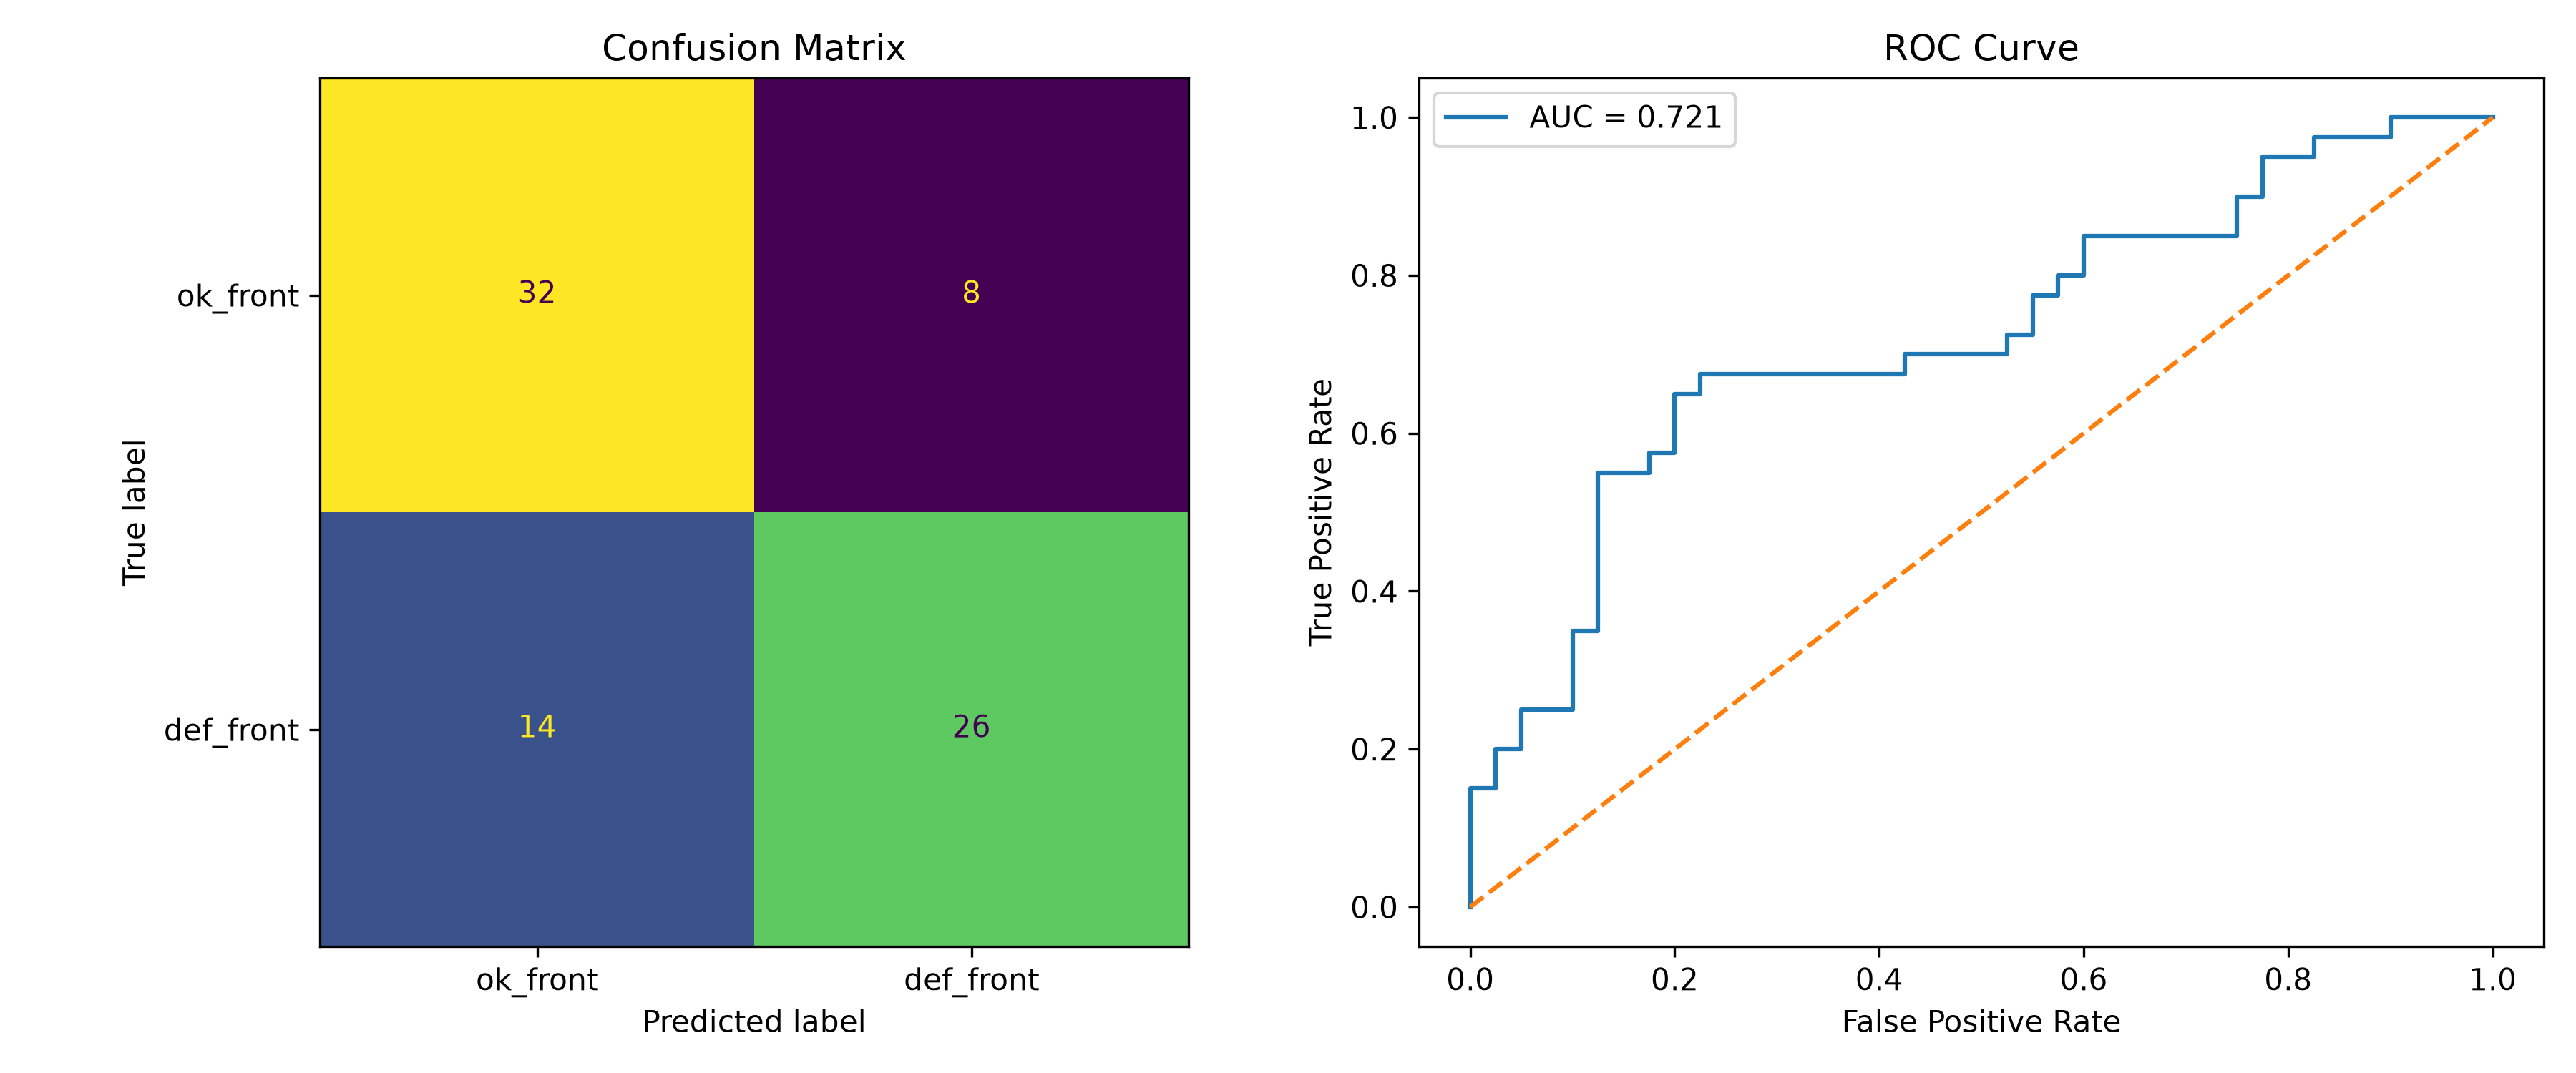

In [74]:
from PIL import Image

Image.open(figure_path)

In [77]:
display_labels=[
    "OK",
    "Defect",
]

In [78]:
from src.evaluate import failure_cases
from src import data_prep

root = data_prep.find_data_root()

test_items = data_prep.load_split(
    "v1",
    "test",
    root,
)

failures = failure_cases(
    test_items,
    y_true,
    y_pred,
    y_prob,
)

len(failures)

20

In [79]:
failures[:5]

[{'image': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1001.jpeg',
  'actual': 'ok_front',
  'predicted': 'def_front',
  'p_defect': 0.5548},
 {'image': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1021.jpeg',
  'actual': 'ok_front',
  'predicted': 'def_front',
  'p_defect': 0.5566},
 {'image': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1066.jpeg',
  'actual': 'ok_front',
  'predicted': 'def_front',
  'p_defect': 0.5836},
 {'image': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1121.jpeg',
  'actual': 'ok_front',
  'predicted': 'def_front',
  'p_defect': 0.5096},
 {'image': 'C:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\data\\casting_data\\test\\ok_front\\cast_ok_0_1137.jpeg',
  'actual': 'ok_front',
  'predicted': 'def_front',
  'p_defect': 0.5113}]

In [93]:
!python -m src.train


Class Distribution After Split
ok_front    Train : 34   Validation :  6
def_front   Train : 34   Validation :  6

Stratified split completed
Training Samples   : 68
Validation Samples : 12

Prepared Split Records
Train      : 68
Validation : 12
Test       : 80
Saved: train.json (68 images)
Saved: val.json (12 images)
Saved: test.json (80 images)
Saved: metadata.json
Dataset version directory created:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\artifacts\splits\v1
Training Images : 80
Testing Images  : 80
Training samples available for splitting: 80
Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Epoch 1/4 | Train F1: 0.4615 | Val F1: 0.7273
Epoch 2/4 | Train F1: 0.5152 | Val F1: 0.7059
Epoch 3/4 | Train F1: 0.6286 | Val F1: 0.6667
Epoch 4/4 | Train F1: 0.5714 | Val F1: 0.6667
Early stopping triggered.

Training completed successfully.
Best Validation F1 : 0.7273
Best Epoch         : 1


2026/07/21 09:01:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [94]:
import mlflow
import config

runs = mlflow.search_runs(
    experiment_names=[config.MLFLOW_EXPERIMENT]
)

runs[
    [
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1",
        "metrics.roc_auc",
        "status",
    ]
].head()

,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc,status
0,resnet18_freeze_True,0.5,0.5,1.0,0.666667,0.714375,FINISHED
1,resnet18_freeze_True,NaN,NaN,NaN,NaN,NaN,FINISHED
2,resnet18_freeze_True,NaN,NaN,NaN,NaN,NaN,FINISHED
3,intelligent-eel-228,NaN,NaN,NaN,NaN,NaN,FINISHED
4,capable-auk-759,NaN,NaN,NaN,NaN,NaN,FINISHED


## **Stage 3.2 — Model Registry & Promotion** <font color="red">[5 marks]</font>

- **3.2.1 — Best model registered in MLflow Registry [2]**
- **3.2.2 — Promotion to production alias + version history [3]**

**Objective:** Register and promote the best model.

**Implement in:** src/train.py (MLflow registry)

**Inputs → Outputs:** best run → registered model + @production alias

**TODO:** register_model(casting_defect_classifier) (3.2.1); set_registered_model_alias('production', v) with version history (3.2.2).

**Document here:** the registry version + alias (screenshot the MLflow Models page).

In [ ]:
# TODO 3.2.1-3.2.2: MlflowClient().get_model_version_by_alias(config.REGISTERED_MODEL, 'production')


In [97]:
from mlflow import MlflowClient
import config

client = MlflowClient()

production_model = client.get_model_version_by_alias(
    config.REGISTERED_MODEL,
    config.PRODUCTION_ALIAS,
)

print(production_model)

<ModelVersion: aliases=['production'], creation_timestamp=1784608500051, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1784608500051, metrics=[<Metric: dataset_digest=None, dataset_name=None, key='accuracy', model_id='m-db8dc67253df4ed189e4b671c7d07c11', run_id='b9f32dd6cfea4ade8d2984d542805686', step=0, timestamp=1784608488445, value=0.5>,
 <Metric: dataset_digest=None, dataset_name=None, key='best_val_f1', model_id='m-db8dc67253df4ed189e4b671c7d07c11', run_id='b9f32dd6cfea4ade8d2984d542805686', step=0, timestamp=1784608500192, value=0.7272727272727273>,
 <Metric: dataset_digest=None, dataset_name=None, key='f1', model_id='m-db8dc67253df4ed189e4b671c7d07c11', run_id='b9f32dd6cfea4ade8d2984d542805686', step=0, timestamp=1784608488445, value=0.6666666666666666>,
 <Metric: dataset_digest=None, dataset_name=None, key='macro_f1', model_id='m-db8dc67253df4ed189e4b671c7d07c11', run_id='b9f32dd6cfea4ade8d2984d542805686', step=0, timestamp=1784608488

In [98]:
print("Model Name :", production_model.name)
print("Version    :", production_model.version)
print("Alias      :", config.PRODUCTION_ALIAS)
print("Run ID     :", production_model.run_id)

Model Name : casting_defect_classifier
Version    : 1
Alias      : production
Run ID     : b9f32dd6cfea4ade8d2984d542805686


Model Registry & Promotion:
The trained ResNet18 model was registered in the MLflow Model Registry as casting_defect_classifier. The first registered version (Version 1) was promoted to the production alias using the MLflow Client API. The registry maintains version history, allowing future model versions to be compared and promoted without overwriting previous models.

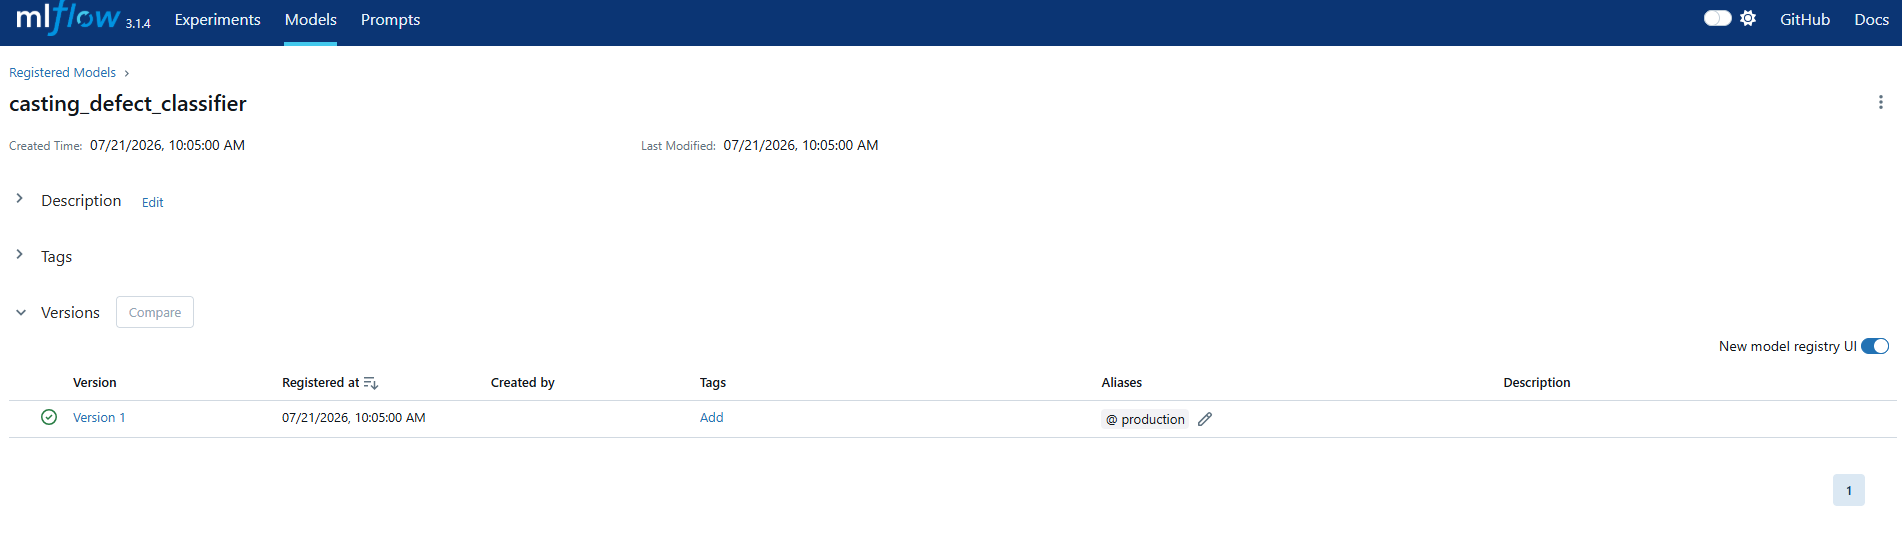

## **Stage 3.3 — FastAPI Inference Service** <font color="red">[6 marks]</font>

- **3.3.1 — Image /predict + /health + logging + validation [4]** — *to be done in app.py*
- **3.3.2 — Live call demonstrated in-notebook [2]** — *to be done in this notebook*

**Objective:** Serve the model behind an image API and demonstrate it.

**Implement in:** app.py (+ a TestClient demo here)

**Inputs → Outputs:** image upload → {label, prob_defect, confidence}; /health; predictions logged

**TODO:** implement /health + POST /predict (UploadFile) with validation (bad image 400, no-model 503) + logging (3.3.1, in app.py); demo with TestClient on a sample image (3.3.2, here).

**Document here:** the live request/response (TestClient output).

In [ ]:
# TODO 3.3.2: with TestClient(app.app) as c: call /health and POST a sample image to /predict


In [122]:
import importlib
import app

importlib.reload(app)

<module 'app' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\app.py'>

In [100]:
from app import _load, _state

_load()

print(_state["model"] is not None)
print(_state["tf"] is not None)
print(_state["meta"])

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
True
True
{'backbone': 'resnet18', 'freeze_backbone': True, 'best_epoch': 1, 'epochs_trained': 4, 'best_val_f1': 0.7272727272727273, 'learning_rate': 0.001, 'batch_size': 32, 'random_seed': 42}


In [106]:
from fastapi.testclient import TestClient
import importlib
import app

importlib.reload(app)

with TestClient(app.app) as client:
    response = client.get("/health")

print(response.status_code)
print(response.json())

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
200
{'status': 'healthy', 'model_loaded': True, 'classes': ['ok_front', 'def_front'], 'positive_class': 'def_front', 'model_info': {'backbone': 'resnet18', 'freeze_backbone': True, 'best_epoch': 1, 'epochs_trained': 4, 'best_val_f1': 0.7272727272727273, 'learning_rate': 0.001, 'batch_size': 32, 'random_seed': 42}, 'registered_model': 'casting_defect_classifier'}


In [110]:
from fastapi.testclient import TestClient
from pathlib import Path

In [112]:
sample_image = (
    config.DATA_DIR
    / "casting_data"
    / "test"
    / "def_front"
    / "cast_def_0_1063.jpeg"
)

print(sample_image.exists())

True


In [113]:
with TestClient(app.app) as client:

    response = client.get("/health")

    print("Health Status Code :", response.status_code)
    print(response.json())

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Health Status Code : 200
{'status': 'healthy', 'model_loaded': True, 'classes': ['ok_front', 'def_front'], 'positive_class': 'def_front', 'model_info': {'backbone': 'resnet18', 'freeze_backbone': True, 'best_epoch': 1, 'epochs_trained': 4, 'best_val_f1': 0.7272727272727273, 'learning_rate': 0.001, 'batch_size': 32, 'random_seed': 42}, 'registered_model': 'casting_defect_classifier', 'loaded_at': 1784619539.046671}


In [117]:
with TestClient(app.app) as client:

    with open(sample_image, "rb") as f:

        response = client.post(
            "/predict",
            files={
                "file": (
                    sample_image.name,
                    f,
                    "image/jpeg",
                )
            },
        )

    print("Predict Status Code :", response.status_code)
    print(response.json())

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
Predict Status Code : 200
{'label': 'def_front', 'is_defective': True, 'prob_defect': 0.5641, 'confidence': 0.5641}


In [115]:
import io

with TestClient(app.app) as client:

    fake_file = io.BytesIO(b"This is not an image")

    response = client.post(
        "/predict",
        files={
            "file": (
                "invalid.txt",
                fake_file,
                "text/plain",
            )
        },
    )

    print(response.status_code)
    print(response.json())

Total Parameters     : 11,177,538
Trainable Parameters : 1,026
Frozen Parameters     : 11,176,512
400
{'detail': 'Invalid image file.'}


## **Stage 3.4 — Containerisation & CI/CD** <font color="red">[7 marks]</font>

- **3.4.1 — Valid Dockerfile [3]** — *to be done in this notebook and the report*
- **3.4.2 — GitHub Actions CI + passing-test evidence [4]** — *to be done in this notebook and the report*

**Objective:** Containerise and automate tests.

**Implement in:** Dockerfile + .github/workflows/ci.yml (provided — review + evidence them)

**Inputs → Outputs:** code → Docker image; push/PR → CI runs pytest + docker build

**TODO:** show the Dockerfile (3.4.1); run pytest here + include a screenshot of the green CI run and successful docker build (3.4.2).

**Document here:** pytest output + Docker/CI screenshots **(Note: Don't add a repo link)**

In [118]:
# TODO 3.4.1-3.4.2: print Dockerfile + ci.yml; run pytest; embed your CI/Docker screenshots


In [119]:
print(open("Dockerfile").read())

# Casting Defect Detection â€” inference service image (CPU)
FROM python:3.11-slim

# libgl/libglib are needed by Pillow/torchvision image ops at runtime
RUN apt-get update && apt-get install -y --no-install-recommends \
        libgl1 libglib2.0-0 && rm -rf /var/lib/apt/lists/*

WORKDIR /app

# Install CPU-only torch wheels (smaller, no CUDA) then the rest
COPY requirements.txt .
RUN pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cpu \
        torch==2.8.0 torchvision==0.23.0 \
 && pip install --no-cache-dir \
        "mlflow==3.1.4" "fastapi==0.128.8" "uvicorn==0.39.0" "python-multipart==0.0.20" \
        "evidently==0.7.20" "scikit-learn==1.6.1" "pillow==11.3.0" numpy pandas matplotlib

# App code + trained model artifacts
COPY config.py app.py ./
COPY src ./src
COPY artifacts/model.pt artifacts/model_meta.json ./artifacts/

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



In [1]:
print(open(".github/workflows/ci.yml").read())

name: ci

on:
  push:
    branches:
    - main
    - develop
  pull_request:

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install CPU dependencies
        run: |
          python -m pip install --upgrade pip
          pip install --index-url https://download.pytorch.org/whl/cpu torch==2.8.0 torchvision==0.23.0
          pip install "mlflow==3.1.4" "fastapi==0.128.8" "uvicorn==0.39.0" "python-multipart==0.0.20" \
                      "evidently==0.7.20" "scikit-learn==1.6.1" "pillow==11.3.0" numpy pandas matplotlib pytest

      - name: Run tests
        run: pytest -q

      - name: Validate Docker build
        run: docker build -t casting-defect-api:ci .



In [123]:
import importlib
from src import monitoring

# Reload project module after making changes
importlib.reload(monitoring)

<module 'src.monitoring' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\monitoring.py'>

In [124]:
!pytest -q

........                                                                 [100%]
8 passed in 11.98s


In [128]:
!docker build -t casting-defect-api .

#0 building with "desktop-linux" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 982B 0.1s done
#1 DONE 0.1s

#2 [internal] load metadata for docker.io/library/python:3.11-slim
#2 DONE 3.3s

#3 [internal] load .dockerignore
#3 transferring context: 2B done
#3 DONE 0.1s

#4 [internal] load build context
#4 transferring context: 11.04MB 4.9s
#4 ...

#5 [1/8] FROM docker.io/library/python:3.11-slim@sha256:db3ff2e1800a8581e2c48a27c3995339d47bdf046da21c7627accd3d51053a93
#5 resolve docker.io/library/python:3.11-slim@sha256:db3ff2e1800a8581e2c48a27c3995339d47bdf046da21c7627accd3d51053a93 0.1s done
#5 sha256:c89b9f64c028c19ba92e195d7589d914b9cd1fc69f3c3dfeb931e93876ac2064 248B / 248B 0.3s done
#5 sha256:6b265b8eae4a26a263eb55546aa430c1eef37032a7cd86393d98c6b779f28319 14.42MB / 14.42MB 6.2s done
#5 sha256:062e450697faa5f02a3a74eba9864ee4d79bc9cfbd65769fc6cdff2c05c6a053 17.83MB / 29.78MB 7.8s
#5 sha256:9775d166087aba0afe5ba9a88859c04

![alt text](image.png)

![alt text](image-1.png)

![alt text](image-2.png)